# Генерация синтетического графа 

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pymoo
from pymoo.core.problem import Problem

import pandas as pd 


In [2]:
node_positions = {
    0: (-25.874734, -46.449444),
    1: (-25.973882, -46.350297),
    2: (-25.977159, -46.216734),
    3: (-26.083682, -46.349477),
    4: (-26.083682, -46.506802),
    5: (-26.086140, -46.217553),
    6: (-26.218064, -45.884057),
    7: (-26.218883, -46.099560),
    8: (-26.085320, -45.836531),
    9: (-26.376208, -45.978288),
    10: (-26.461426, -46.044660),
    11: (-26.331961, -46.386350),
    12: (-26.504035, -45.936499),
    13: (-26.439302, -45.855378),
    14: (-26.084501, -45.987301)
}

edges = [
    (0, 1, 8), (1, 0, 8), (1, 2, 2), (1, 3, 3), (1, 4, 6),
    (2, 1, 2), (2, 5, 3), (3, 1, 3), (3, 4, 4), (3, 5, 4), (3, 11, 10),
    (4, 1, 6), (4, 3, 4), (5, 2, 3), (5, 3, 4), (5, 7, 2), (5, 14, 3),
    (6, 9, 7), (6, 14, 2), (7, 5, 2), (7, 9, 8), (7, 14, 2),
    (8, 14, 8), (9, 6, 7), (9, 7, 8), (9, 10, 5), (9, 12, 10), (9, 13, 8),
    (10, 9, 5), (10, 11, 10), (10, 12, 5), (11, 3, 10), (11, 10, 10),
    (12, 9, 10), (12, 10, 5), (12, 13, 2), (13, 9, 8), (13, 12, 2),
    (14, 5, 3), (14, 6, 2), (14, 7, 2), (14, 8, 8)
]

In [3]:
G = nx.DiGraph()
for node_id, (lat, lon) in node_positions.items():
    G.add_node(node_id, pos=(lon, lat))

In [4]:
G.add_weighted_edges_from(edges)

pos = nx.get_node_attributes(G, 'pos')

In [5]:
nodes = sorted(G.nodes)
np.random.seed(42)
od_matrix = pd.DataFrame(np.random.randint(0, 200, size=(len(nodes), len(nodes))),
                         index=nodes, columns=nodes)
np.fill_diagonal(od_matrix.values, 0)
od_matrix

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0,179,92,14,106,71,188,20,102,121,74,87,116,99,103
1,151,0,149,52,1,87,157,37,129,191,187,20,160,57,21
2,88,48,0,169,187,14,189,189,174,189,50,107,54,63,130
3,50,134,20,0,166,17,131,88,59,13,8,89,52,129,83
4,91,110,187,198,0,7,174,34,80,163,49,103,131,1,133
5,53,105,3,53,190,0,43,161,189,13,94,47,14,199,189
6,39,81,110,52,23,153,0,123,40,156,14,44,64,88,70
7,8,87,128,135,62,138,80,0,162,162,32,122,4,40,27
8,134,71,11,161,32,47,150,61,0,98,171,103,34,192,100
9,174,130,0,4,141,102,26,136,14,0,41,123,178,62,95


In [6]:
od_matrix

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0,179,92,14,106,71,188,20,102,121,74,87,116,99,103
1,151,0,149,52,1,87,157,37,129,191,187,20,160,57,21
2,88,48,0,169,187,14,189,189,174,189,50,107,54,63,130
3,50,134,20,0,166,17,131,88,59,13,8,89,52,129,83
4,91,110,187,198,0,7,174,34,80,163,49,103,131,1,133
5,53,105,3,53,190,0,43,161,189,13,94,47,14,199,189
6,39,81,110,52,23,153,0,123,40,156,14,44,64,88,70
7,8,87,128,135,62,138,80,0,162,162,32,122,4,40,27
8,134,71,11,161,32,47,150,61,0,98,171,103,34,192,100
9,174,130,0,4,141,102,26,136,14,0,41,123,178,62,95


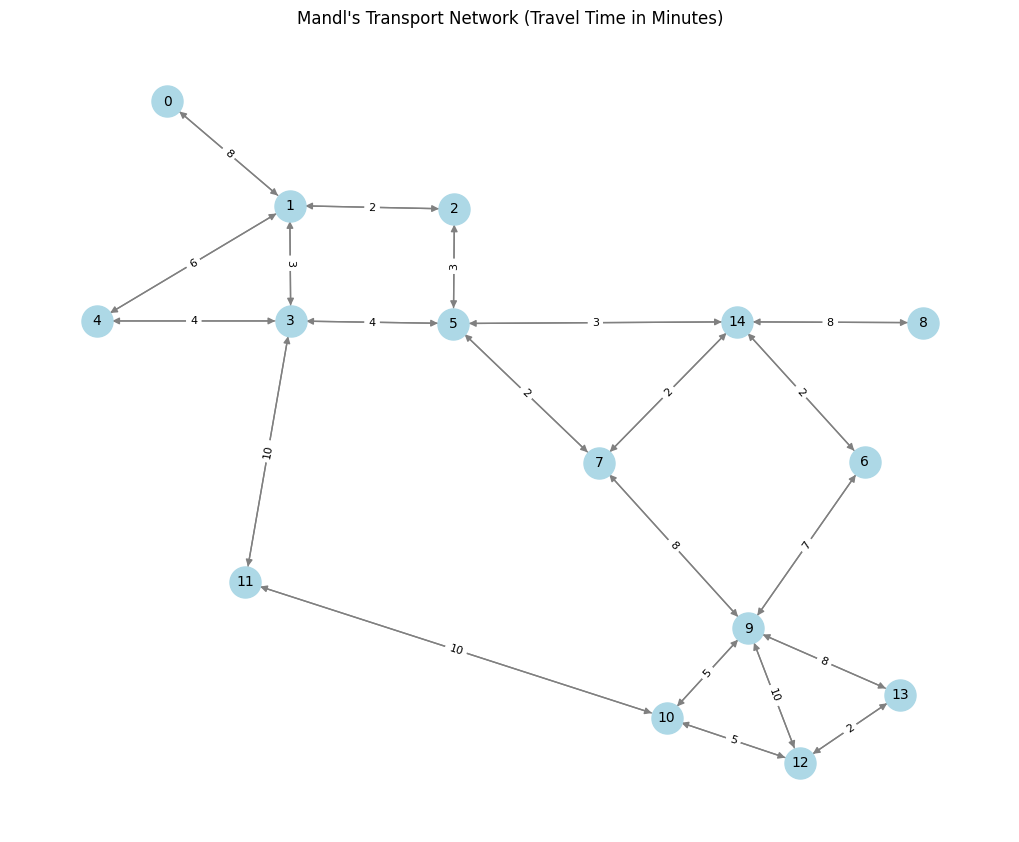

In [6]:
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_size=500, node_color="lightblue", edge_color="gray", font_size=10)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8)

plt.title("Mandl's Transport Network (Travel Time in Minutes)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

# NSGA-II

## Генерация случайного набора маршрутов для заданного количества остановок и маршрутов (прошлая версия)

### Старая версия

In [29]:
ROUTES_KEY = 'routes'
WEIGHT_KEY = 'weight' # или другое значение времени в пути

In [30]:
def demand_satisfaction(graph : nx.Graph, matrix) -> float:
        total_demand = matrix.sum().sum()
        satisfied_demand = 0 

        for origin in matrix.index:
            for destination in matrix.columns:
                if origin == destination:
                    continue

                demand = matrix.at[origin, destination]
                if demand == 0:
                    continue

                try:
                    path = nx.shortest_path(graph, source=origin, target=destination, weight = WEIGHT_KEY)
                    if path: 
                        satisfied_demand += demand
                except nx.NetworkXNoPath:
                        pass
        unmet_demand = total_demand - satisfied_demand
        return unmet_demand

In [31]:
from pymoo.core.problem import Problem as MyProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from enum import Enum
import networkx as nx
import time # testing purposes
from networkx.algorithms.approximation import simulated_annealing_tsp

class FitnessType(Enum):
    A = 'Моя функция А которая хочет быть мин'
    B = 'Моя функция B которая тоже хочет быть мин'

class Problem(MyProblem): 

    def __init__(
            self,
            graph : nx.DiGraph,
            max_routes : int,
            od_matrix : pd.DataFrame
        ):
        n = len(graph.nodes)
        k = max_routes
        self.n = n
        self.k = k
        self.graph = self._preproccess_graph(graph)
        self.matrix = od_matrix
        super().__init__(
            n_var = n*k, # кол-во переменных в решении
            n_obj = len(list(FitnessType)), # кол-во целевых функций (оптимизируемых)
            n_constr = 0, # кол-во ограничений
            xl = 0,
            xu = 1,
            type_var = int # Дискретные переменные (метки)
        )

    # препроцессинг графа – добавление мареров маршрутов на ребра
    def _preproccess_graph(self, graph : nx.Graph):
        graph = graph.copy()
        for u, v, d in graph.edges(data=True):
            d[ROUTES_KEY] = []
        return graph

    # преобразование решения из вектора в матрицу маршрутов
    def _solution_1d_to_2d(self, solution_1d : np.array) -> np.array:
        solution_2d = np.array([[round(solution_1d[i+j*self.k]) for i in range(self.n)] for j in range(self.k)])
        return solution_2d
    
    # минимизация кол-ва маршрутов
    def _evaluate_a(self, graph : nx.Graph) -> float: 
        routes = {}
        for u,v,d in graph.edges(data=True):
            weight = d[WEIGHT_KEY]
            for route in d[ROUTES_KEY]:
                if not route in routes:
                    routes[route] = [] 
                routes[route].append(weight)
        return sum(len(weights)*sum(weights) for route, weights in routes.items())
    
    # минимизируем / удовлетворяем матрицу спроса с матрицей маршрутов
    def _evaluate_b(self, graph : nx.Graph) -> float: # здесь особое внимание, тоже минимизируется
        unmet_demand = demand_satisfaction(graph, self.matrix)
        return unmet_demand

    def _evaluate_fitness(self, fitness_type : FitnessType, graph : nx.Graph): # 
        if fitness_type == FitnessType.A:
            return self._evaluate_a(graph)
        if fitness_type == FitnessType.B:
            return self._evaluate_b(graph)
        return 0

    def _evaluate_fitnesses(self, graph : nx.Graph):
        return {fitness_type : self._evaluate_fitness(fitness_type, graph) for fitness_type in list(FitnessType)}

    def _solution_to_graph(self, solution_1d : np.array) -> nx.Graph:
        solution_2d = self._solution_1d_to_2d(solution_1d)

        def row_to_nodes(row : np.array):
            nodes_to_visit = [i for i,v in enumerate(row) if v==1]
            return nodes_to_visit

        routes_nodes = [row_to_nodes(row) for row in solution_2d]
        graph = self.graph.copy()

        def nodes_to_route(nodes : list[int]) -> list[int]:
            # тут решается ТСП на этих нодах на твоем графе G*'
            return nx.algorithms.approximation.traveling_salesman_problem(
                    graph, 
                    weight=WEIGHT_KEY, 
                    nodes=nodes,
                    cycle=False,
                    method=simulated_annealing_tsp,
                    init_cycle="greedy"
                )
                
        routes = [nodes_to_route(route_nodes) for route_nodes in routes_nodes] # тут какие мы ноды должны посетить каждым маршрутом из k маршрутов

        # далее чето делаешь короче с графом чтоб пометить что через него проходит твой маршрут
        for i,route in enumerate(routes):
            for j in range(len(route)-1):
                node_from = route[j]
                node_to = route[j+1]
                graph.edges[node_from, node_to][ROUTES_KEY].append(i)
        return graph

    def _evaluate(self, solutions, out, *args, **kwargs):
        # обязательный метод в пиму, он в него стучит когда проверяет решения и ждет что ты ему отдашь обратно чиселки
        # solutions -- это твое поколение, по сути набор из k особей, каждая из которых имеет n генов
        # каждый ген -- 0 или 1, в зависимости от того едем мы в эту остановку или нет
        # соответственно в графе ноды надо нумеровать с 0
        # print(f"Evaluating {len(solutions)} solutions...")
        solutions_fitnesses = {fitness_type : [] for fitness_type in list(FitnessType)} # это тоже не меняй

        for solution in solutions:

            graph = self._solution_to_graph(solution)

            fitnesses = self._evaluate_fitnesses(graph) # и это тоже

            for ft, value in fitnesses.items(): # тоже можешь не трогать
                solutions_fitnesses[ft].append(value) # тоже

        out["F"] = np.column_stack([v for v in solutions_fitnesses.values()]) # это не меняй

In [32]:
k = 10
problem = Problem(G, k, od_matrix)
algorithm = NSGA2(pop_size=10)
res = minimize(problem, algorithm, ('n_gen', 30), seed=42, verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       10 |      1 |             - |             -
     2 |       20 |      1 |  0.000000E+00 |             f
     3 |       30 |      1 |  0.000000E+00 |             f
     4 |       40 |      1 |  0.000000E+00 |             f
     5 |       50 |      1 |  0.000000E+00 |             f
     6 |       60 |      1 |  0.000000E+00 |             f
     7 |       70 |      1 |  0.000000E+00 |             f
     8 |       80 |      1 |  0.000000E+00 |             f
     9 |       90 |      1 |  0.000000E+00 |             f
    10 |      100 |      1 |  0.000000E+00 |             f
    11 |      110 |      1 |  0.000000E+00 |             f
    12 |      120 |      1 |  0.000000E+00 |             f
    13 |      130 |      1 |  0.000000E+00 |             f
    14 |      140 |      1 |  0.000000E+00 |             f
    15 |      150 |      1 |  0.000000E+00 |             f
    16 |      160 |      1 |  0.000000E+00 |            

In [43]:
res.X[0]

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258,
       0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497,
       0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914,
       0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998,
       0.78517596, 0.19967378, 0.51423444, 0.59241457, 0.04645041,
       0.60754485, 0.17052412, 0.06505159, 0.94888554, 0.96563203,
       0.80839735, 0.30461377, 0.09767211, 0.68423303, 0.44015249,
       0.12203823, 0.49517691, 0.03438852, 0.9093204 , 0.25877998,
       0.66252228, 0.31171108, 0.52006802, 0.54671028, 0.18485446,
       0.96958463, 0.77513282, 0.93949894, 0.89482735, 0.59789998,
       0.92187424, 0.0884925 , 0.19598286, 0.04522729, 0.32533033,
       0.38867729, 0.27134903, 0.82873751, 0.35675333, 0.28093451,
       0.54269608, 0.14092422, 0.80219698, 0.07455064, 0.98688694,
       0.77224477, 0.19871568, 0.00552212, 0.81546143, 0.70685

In [44]:
solution_1d = res.X[0]

# Преобразование решения из 1D в 2D
solution_2d = problem._solution_1d_to_2d(solution_1d)
print("2D Solution:")
print(solution_2d)

# Обновление графа с использованием решения
updated_graph = problem._solution_to_graph(solution_1d)
print("Updated Graph:")
print(updated_graph.edges(data=True))

2D Solution:
[[0 1 1 1 0 0 0 1 1 1 0 1 1 0 0]
 [0 1 1 0 0 0 0 1 0 0 1 0 0 0 0]
 [1 0 0 0 0 1 0 1 1 0 1 0 0 1 1]
 [1 0 0 1 1 1 0 0 1 0 0 0 0 1 0]
 [0 0 0 1 0 1 0 1 1 0 1 1 1 1 1]
 [1 1 1 1 1 1 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 1 0 1 0 1 1 0 0 1 1]
 [1 0 0 1 1 1 1 0 0 0 1 1 0 0 0]
 [1 1 0 0 0 0 1 1 1 0 0 1 1 1 1]
 [0 1 1 1 1 0 1 0 0 0 0 1 0 1 1]]
Updated Graph:
[(0, 1, {'weight': 8, 'routes': [2, 3, 5, 8, 0, 2, 5, 7, 8, 9, 2, 5, 9, 0, 3, 5, 6, 7, 8, 9, 3, 6, 7, 1, 2, 5, 7, 0, 1, 3, 4, 6, 7, 8, 9, 0, 2, 3, 5, 7, 8, 0, 1, 2, 9, 2, 5, 7, 8, 9, 1, 5, 6, 7, 8, 9, 5, 6, 7, 8, 0, 1, 3, 4, 5, 6, 7, 9, 5, 6, 8, 9, 2, 3, 5, 0, 2, 3, 5, 7, 9, 2, 3, 5, 7, 8, 9, 2, 6, 7, 8, 9, 0, 2, 3, 5, 7, 9, 0, 3, 5, 6, 7, 9, 3, 8, 0, 5, 7, 9, 0, 1, 3, 4, 6, 7, 9, 2, 5, 6, 7, 8, 0, 3, 5, 6, 7, 8, 9, 2, 3, 5, 2, 5, 6, 9, 0, 2, 5, 6, 7, 8, 9, 1, 2, 3, 7, 9, 3, 5, 6, 7, 8, 9, 8, 0, 2, 3, 5, 6, 8, 9, 0, 5, 6, 7, 9, 1, 2, 5, 7, 8, 9, 0, 5, 6, 2, 3, 5, 7, 8, 5, 7, 8, 3, 5, 6, 7, 0, 2, 5, 6, 9, 0, 2, 5, 6, 8, 9, 2, 3, 8, 2,

In [45]:
updated_graph

### Новая версия

In [7]:
from copy import deepcopy
import numpy as np
from networkx.algorithms.approximation import simulated_annealing_tsp

ROUTES_KEY = 'routes'
WEIGHT_KEY = 'weight' # или другое значение времени в пути

# преобразование решения из вектора в матрицу маршрутов
def _solution_1d_to_2d(solution_1d : np.array, n : int, k : int) -> np.array:
    solution_2d = np.array([[round(solution_1d[i+j*k]) for i in range(n)] for j in range(k)])
    return solution_2d

def _solution_to_graph(solution_1d : np.array, graph, n, k) -> nx.Graph:
    solution_2d = _solution_1d_to_2d(solution_1d, n, k)

    def row_to_nodes(row : np.array):
        nodes_to_visit = [i for i,v in enumerate(row) if v==1]
        return nodes_to_visit

    routes_nodes = [row_to_nodes(row) for row in solution_2d]
    graph = deepcopy(graph)

    def nodes_to_route(nodes : list[int]) -> list[int]:
        # тут решается ТСП на этих нодах на твоем графе G*'
        route = nx.algorithms.approximation.traveling_salesman_problem(
                graph, 
                weight=WEIGHT_KEY, 
                nodes=nodes,
                cycle=False,
                method=simulated_annealing_tsp,
                init_cycle="greedy"
            )
        return route
            
    routes = [nodes_to_route(route_nodes) for route_nodes in routes_nodes] # тут какие мы ноды должны посетить каждым маршрутом из k маршрутов
    print(routes)

    # далее чето делаешь короче с графом чтоб пометить что через него проходит твой маршрут
    for i,route in enumerate(routes):
        for j in range(len(route)-1):
            node_from = route[j]
            node_to = route[j+1]
            graph.edges[node_from, node_to][ROUTES_KEY].append(i)
    return graph

In [8]:
from copy import deepcopy
from pymoo.core.problem import Problem as MyProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from enum import Enum
import networkx as nx

class FitnessType(Enum):
    COST_PENALTY = 'Штраф за маршруты и их длину'
    B = 'Моя функция B которая тоже хочет быть мин'
    TRAVEL_TIME = ''

class Problem(MyProblem): 

    def __init__(
            self,
            graph : nx.DiGraph,
            max_routes : int,
            od_matrix : pd.DataFrame
        ):
        n = len(graph.nodes)
        k = max_routes
        self.n = n
        self.k = k
        self.graph = self._preproccess_graph(graph)
        self.matrix = od_matrix
        super().__init__(
            n_var = n*k, # кол-во переменных в решении
            n_obj = len(list(FitnessType)), # кол-во целевых функций (оптимизируемых)
            n_constr = 0, # кол-во ограничений
            xl = 0,
            xu = 1,
            type_var = int # Дискретные переменные (метки)
        )

    # препроцессинг графа – добавление мареров маршрутов на ребра
    def _preproccess_graph(self, graph : nx.Graph):
        graph = deepcopy(graph)
        for u, v, d in graph.edges(data=True):
            d[ROUTES_KEY] = []
        return graph
    
    # минимизация кол-ва маршрутов
    def _evaluate_cost_penalty(self, graph : nx.Graph) -> float: 
        routes = {}
        for u,v,d in graph.edges(data=True):
            weight = d[WEIGHT_KEY]
            for route in d[ROUTES_KEY]:
                if not route in routes:
                    routes[route] = [] 
                routes[route].append(weight)
        return sum([len(weights)*sum(weights) for weights in routes.values()])

    # минимизируем / удовлетворяем матрицу спроса с матрицей маршрутов
    def _evaluate_b(self, graph : nx.Graph) -> float: # здесь особое внимание, тоже минимизируется
        total_demand = self.matrix.sum().sum()
        satisfied_demand = 0 

        for origin in self.matrix.index:
            for destination in self.matrix.columns:
                if origin == destination:
                    continue

                demand = self.matrix.at[origin, destination]
                if demand == 0:
                    continue

                try:
                    path = nx.shortest_path(graph, source=origin, target=destination, weight= WEIGHT_KEY)
                    if path: 
                        satisfied_demand += demand
                except nx.NetworkXNoPath:
                        pass
        unmet_demand = total_demand - satisfied_demand
        return unmet_demand


    def _evaluate_fitness(self, fitness_type : FitnessType, graph : nx.Graph): # 
        if fitness_type == FitnessType.COST_PENALTY:
            return self._evaluate_cost_penalty(graph.copy())
        if fitness_type == FitnessType.B:
            return self._evaluate_b(graph.copy())
        return 0

    def _evaluate_fitnesses(self, graph : nx.Graph):
        return {fitness_type : self._evaluate_fitness(fitness_type, graph) for fitness_type in list(FitnessType)}

    def _evaluate(self, solutions, out, *args, **kwargs):
        # обязательный метод в пиму, он в него стучит когда проверяет решения и ждет что ты ему отдашь обратно чиселки
        # solutions -- это твое поколение, по сути набор из k особей, каждая из которых имеет n генов
        # каждый ген -- 0 или 1, в зависимости от того едем мы в эту остановку или нет
        # соответственно в графе ноды надо нумеровать с 0
        # print(f"Evaluating {len(solutions)} solutions...")
        solutions_fitnesses = {fitness_type : [] for fitness_type in list(FitnessType)} # это тоже не меняй

        for solution in solutions:

            graph = _solution_to_graph(solution, self.graph, self.n, self.k)

            fitnesses = self._evaluate_fitnesses(graph) # и это тоже

            for ft, value in fitnesses.items(): # тоже можешь не трогать
                solutions_fitnesses[ft].append(value) # тоже

        out["F"] = np.column_stack([v for v in solutions_fitnesses.values()]) # это не меняй

In [9]:
k = 10
problem = Problem(G, k, od_matrix)
algorithm = NSGA2(pop_size=10)
res = minimize(problem, algorithm, ('n_gen', 10), seed=42, verbose=True)

[[11, 3, 1, 2, 5, 14, 8, 14, 7, 9, 12], [1, 2, 5, 7, 9, 10], [10, 12, 13, 9, 7, 5, 2, 1, 0, 1, 2, 5, 14, 8], [13, 9, 7, 5, 2, 1, 0, 1, 4, 3, 5, 14, 8], [13, 12, 10, 11, 3, 5, 7, 14, 8], [3, 4, 1, 0, 1, 2, 5, 7, 9, 12], [13, 12, 10, 9, 7, 5, 2, 5, 14], [4, 3, 11, 10, 9, 6, 14, 5, 2, 1, 0], [13, 12, 10, 11, 3, 1, 0, 1, 2, 5, 7, 14, 6, 14, 8], [11, 3, 4, 1, 2, 5, 14, 6, 9, 13]]
[[12, 13, 9, 6, 14, 7, 5, 2, 1, 0, 1, 4, 3, 11], [5, 2, 1, 3, 5, 14, 6, 9, 12, 10], [2, 1, 0, 1, 4, 3, 5, 14, 8, 14, 6, 9, 13, 12], [13, 12, 10, 11, 3, 5, 2, 5, 14, 6, 14, 8, 14, 7], [7, 5, 2, 1, 2, 1, 3, 5, 14, 8, 14, 6, 9, 10, 12, 13], [12, 10, 9, 6, 14, 7, 5, 2, 1, 0, 1, 4, 3, 11], [8, 14, 7, 9, 10, 11, 3, 4, 1, 2, 1, 0], [0, 1, 3, 11, 10, 12, 9, 6, 14, 8], [10, 12, 10, 11, 3, 1, 0, 1, 2, 5, 14, 8], [8, 14, 5, 2, 1, 0, 1, 2, 5, 7, 9, 12]]
[[13, 9, 6, 14, 8, 14, 5, 2, 1, 3, 4], [11, 3, 4, 3, 5, 14, 6, 9, 10, 12], [11, 3, 4, 1, 0, 1, 2, 5, 14, 6, 14, 7], [1, 2, 5, 7, 14, 6], [11, 3, 5, 14, 6, 9, 10, 12], [0, 1, 2,

In [11]:
res.X

array([[0.37689944, 0.28159333, 0.11396242, 0.61173957, 0.12062187,
        0.46077877, 0.20633372, 0.35956557, 0.50341727, 0.69039483,
        0.03823621, 0.96636414, 0.6299466 , 0.08198953, 0.87344737,
        0.86895278, 0.06107796, 0.27683007, 0.79189194, 0.74825969,
        0.19251551, 0.20947221, 0.28446232, 0.48452299, 0.61825477,
        0.37433899, 0.46253472, 0.74747094, 0.03668538, 0.25243694,
        0.71334959, 0.17137517, 0.07785113, 0.53211349, 0.10099724,
        0.44741237, 0.53261727, 0.23990446, 0.28033813, 0.37728416,
        0.12214504, 0.32207917, 0.18970725, 0.32749735, 0.13573658,
        0.89052728, 0.58650752, 0.67910232, 0.56496533, 0.4984422 ,
        0.08692029, 0.76426426, 0.59107663, 0.89929414, 0.43165955,
        0.1275803 , 0.28377591, 0.36388826, 0.04577934, 0.5707783 ,
        0.35663572, 0.98651525, 0.85612427, 0.23722679, 0.27965257,
        0.17280607, 0.24595773, 0.1606889 , 0.18656702, 0.35832543,
        0.19983175, 0.89676542, 0.08023375, 0.81

In [12]:
res_graph = _solution_to_graph(res.X[0], problem.graph, problem.n, problem.k)

[[9, 12, 10, 11, 3, 5, 14, 8], [4, 1, 2, 5, 14, 8, 14, 6, 9], [4, 3, 5, 7, 9, 10, 12, 13], [0, 1, 3, 5, 14, 6], [12, 13, 9, 6, 14, 8, 14, 7, 5, 3, 11], [11, 3, 1, 2, 5, 7, 9, 12], [13, 12, 10, 11, 3, 1, 2], [10, 11, 3, 1, 2, 5, 14], [8, 14, 6, 9, 12, 9, 7, 5, 3, 4, 1, 0], [2, 5, 7, 9, 10]]


<Axes: >

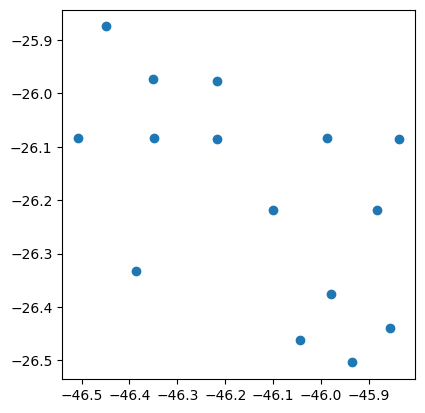

In [13]:
import geopandas as gpd
import shapely

data = [{
    'n': n,
    'geometry':shapely.Point(d['pos']),
} for n,d in res_graph.nodes(data=True)]
nodes_gdf = gpd.GeoDataFrame(data=data, crs=4326).set_index('n')
nodes_gdf.plot()

<Axes: >

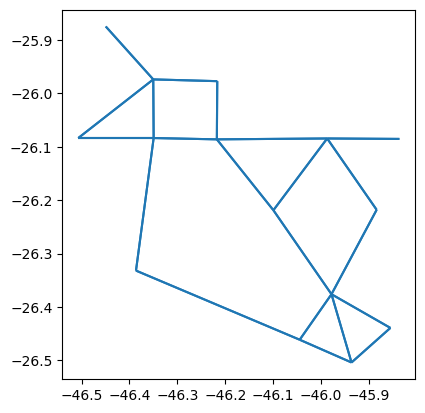

In [14]:
data = [{
    'u': u,
    'v': v,
    'geometry':shapely.LineString([nodes_gdf.loc[u].geometry, nodes_gdf.loc[v].geometry]),
    **d 
} for u,v,d in res_graph.edges(data=True)]
edges_gdf = gpd.GeoDataFrame(data=data, crs=4326)
edges_gdf.plot()

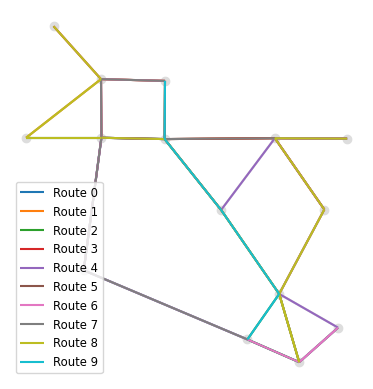

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Создание цветовой карты
colors = list(mcolors.TABLEAU_COLORS.values())

# Создание фигуры и оси
fig, ax = plt.subplots()

# Отображение узлов и ребер графа
nodes_gdf.plot(ax=ax, color='#ddd')
edges_gdf.plot(ax=ax, color='#ddd')

# Отображение маршрутов разными цветами
for i in range(k):
    color = colors[i % len(colors)]  # Выбор цвета из цветовой карты
    gdf = edges_gdf[edges_gdf.routes.apply(lambda r: i in r)]
    gdf.plot(ax=ax, color=color, label=f'Route {i}')

# Настройка осей и легенды
ax.set_axis_off()
ax.legend(fontsize='small')  # Уменьшение размера шрифта легенды

# Показать картинку
plt.show()

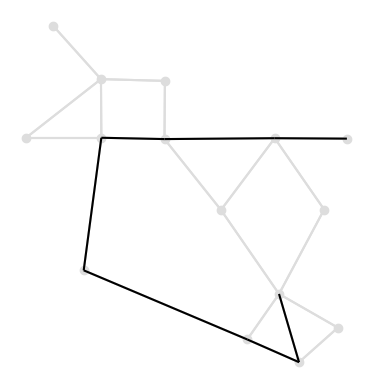

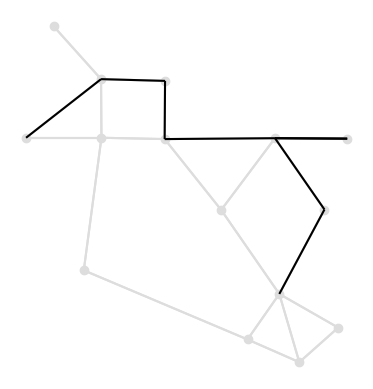

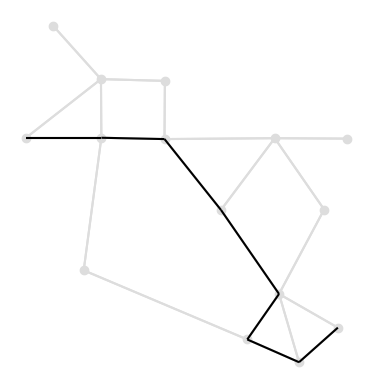

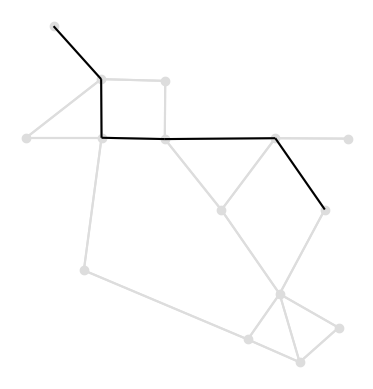

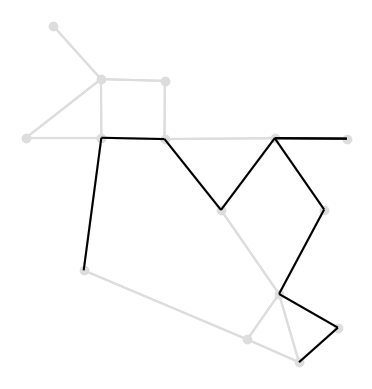

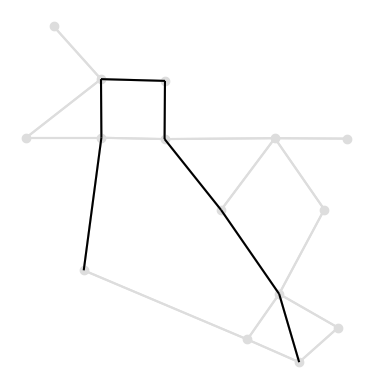

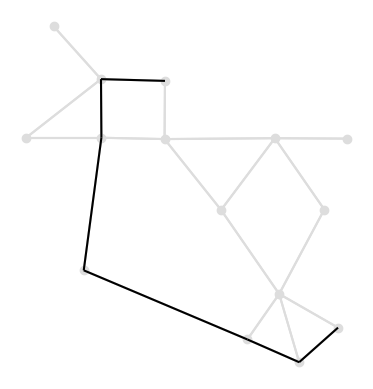

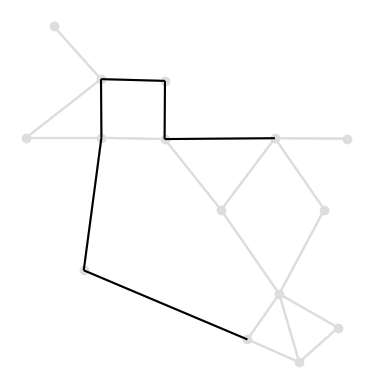

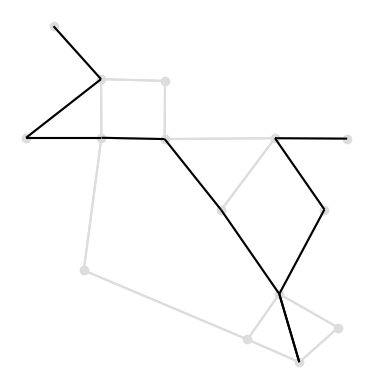

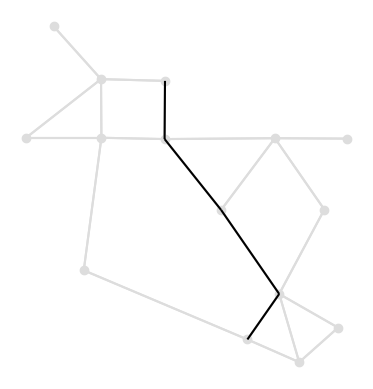

In [15]:
for i in range(k):
    ax = nodes_gdf.plot(color='#ddd')
    edges_gdf.plot(ax=ax, color='#ddd')
    gdf = edges_gdf[edges_gdf.routes.apply(lambda r : i in r)]
    gdf.plot(ax=ax, color='black')
    ax.set_axis_off()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Создание цветовой карты
colors = list(mcolors.TABLEAU_COLORS.values())

# Создание фигуры и оси
fig, ax = plt.subplots()

# Отображение узлов и ребер графа
nodes_gdf.plot(ax=ax, color='#ddd')
edges_gdf.plot(ax=ax, color='#ddd')

# Отображение маршрутов разными цветами
for i in range(k):
    color = colors[i % len(colors)]  # Выбор цвета из цветовой карты
    gdf = edges_gdf[edges_gdf.routes.apply(lambda r: i in r)]
    gdf.plot(ax=ax, color=color, label=f'Route {i}')

# Настройка осей и легенды
ax.set_axis_off()
ax.legend()

# Показать картинку
plt.show()